Install SAM and Dependencies in Colab

In [ ]:
# Install Segment Anything and dependencies
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib torch torchvision
!pip install git+https://github.com/cocodataset/panopticapi.git


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-ubtgweal
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-ubtgweal
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=732632eca1a5b2742121ceb406c1763fd6cbe9edf2407ba29870f9602cbfadc0
  Stored in directory: /tmp/pip-ephem-wheel-cache-98tbhpjt/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O sam_vit_b.pth


--2025-05-21 09:07:21--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.173.166.74, 18.173.166.31, 18.173.166.51, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.173.166.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b.pth’

sam_vit_b.pth       100%[===================>] 357.67M   175MB/s    in 2.0s    

2025-05-21 09:07:23 (175 MB/s) - ‘sam_vit_b.pth’ saved [375042383/375042383]



Load SAM and Prepare Your Maze Image

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving 1.jpg to 1.jpg


In [ ]:
list(uploaded.keys())  # This shows the filename you just uploaded


['1.jpg']

In [ ]:
image_path = list(uploaded.keys())[0]


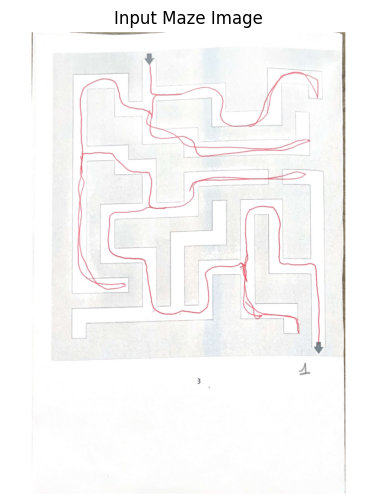

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Use the uploaded image name
image_path = list(uploaded.keys())[0]

# Load and convert image
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis('off')
plt.title("Input Maze Image")
plt.show()


Segment the Red Path Using SAM

In [ ]:
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
import torch

model_type = "vit_b"
checkpoint_path = "sam_vit_b.pth"

sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
sam.to("cuda" if torch.cuda.is_available() else "cpu")

predictor = SamPredictor(sam)
predictor.set_image(image_rgb)

mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(image_rgb)


Identify the Red Path Mask

Loop through each mask

Extract its mean RGB color

Choose the one that’s most likely the red path (based on high red channel)

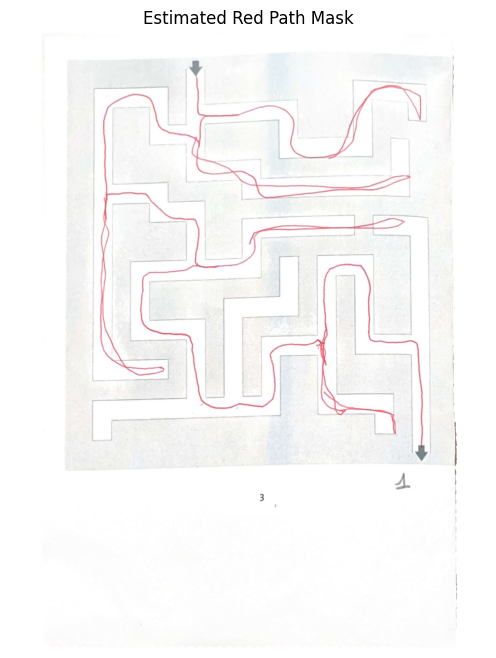

In [ ]:
import numpy as np  # Add this first!

# Convert image to float32 for accurate color math
image_float = image_rgb.astype(np.float32)

# Loop through masks and score based on red intensity
best_score = 0
best_mask = None

for mask in masks:
    m = mask['segmentation']
    # Calculate mean red intensity in the masked region
    red_values = image_float[:, :, 0][m]
    green_values = image_float[:, :, 1][m]
    blue_values = image_float[:, :, 2][m]

    red_score = np.mean(red_values) - 0.5 * (np.mean(green_values) + np.mean(blue_values))

    if red_score > best_score:
        best_score = red_score
        best_mask = m

# Display best mask over original image
masked_image = image_rgb.copy()
masked_image[~best_mask] = [255, 255, 255]  # turn background to white

plt.figure(figsize=(8, 8))
plt.imshow(masked_image)
plt.axis("off")
plt.title("Estimated Red Path Mask")
plt.show()


Estimate MD (Mesure de Déviation)

In [ ]:
# Convert image to grayscale
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Threshold the maze structure (white areas = valid path corridor)
_, maze_mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)  # You may need to adjust 200

# Invert: valid area = 1, wall = 0
maze_valid_area = (maze_mask == 255)

# Get path pixels from SAM
path_pixels = best_mask

# Now estimate deviation: pixels in path but outside valid corridor
off_path_pixels = np.logical_and(path_pixels, ~maze_valid_area)

# Calculate MD as percentage of off-path pixels over total path pixels
num_path_pixels = np.sum(path_pixels)
num_off_path_pixels = np.sum(off_path_pixels)

md_ratio = num_off_path_pixels / num_path_pixels if num_path_pixels > 0 else 0

print(f"Estimated MD (Deviation Ratio): {md_ratio:.2f}")
print(f"Off-path pixels: {num_off_path_pixels}, Total path pixels: {num_path_pixels}")


Estimated MD (Deviation Ratio): 0.02
Off-path pixels: 38541, Total path pixels: 1814380
